# 01-EDA: APTOS 2019 Blindness Detection

This notebook:

1. Installs dependencies (run once per environment)
2. Creates the **shared** 70/15/15 stratified split (seed 42) — created once,
   shared with the group, never regenerated after this
3. Checks image paths, unreadable files, resolution, brightness, contrast,
   black-border variation
4. Visualizes class distribution, resolution/brightness/contrast
   distributions, and sample images per class


## 0. Setup

In [1]:
!pip install -q opencv-python-headless numpy pandas matplotlib seaborn scikit-learn tqdm pyyaml

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\ritik\\anaconda3\\envs\\cv-gpu\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [15]:
# --- Paths ---
LABELS_CSV = "./aptos2019/dataset.csv"     # labels CSV
IMAGE_DIR  = "./aptos2019/images"          # images folder
ID_COL     = "id_code"                   # column with the image filename (no extension)
LABEL_COL  = "diagnosis"                 # column with the class (0-4)
IMG_EXT    = ".png"                      # image file extension

SPLIT_PATH = "./data/splits/aptos_seed42.csv"
CHECKPOINT_DIR = "./artifacts/checkpoints"
RESULTS_DIR = "./artifacts/results"
FIGURES_DIR = "./studies/01_eda/figures"

SEED = 42
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]


In [3]:
import os

for d in [os.path.dirname(SPLIT_PATH), CHECKPOINT_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("Labels CSV exists:", os.path.exists(LABELS_CSV))
print("Image dir exists:", os.path.exists(IMAGE_DIR))


Labels CSV exists: True
Image dir exists: True


In [4]:
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")


c:\Users\ritik\anaconda3\envs\cv-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Shared split
Created once (70/15/15 stratified, seed 42). Skips if it already exists.

In [5]:
if os.path.exists(SPLIT_PATH):
    print(f"Using existing split at {SPLIT_PATH}")
else:
    df = pd.read_csv(LABELS_CSV)
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df[LABEL_COL], random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df[LABEL_COL], random_state=SEED)
    train_df = train_df.copy(); train_df["split"] = "train"
    val_df = val_df.copy(); val_df["split"] = "val"
    test_df = test_df.copy(); test_df["split"] = "test"
    full = pd.concat([train_df, val_df, test_df]).sort_index().reset_index(drop=True)
    full.to_csv(SPLIT_PATH, index=False)
    print(f"Wrote {len(full)} rows to {SPLIT_PATH}")

split_df = pd.read_csv(SPLIT_PATH)
print(split_df["split"].value_counts())


Using existing split at ./data/splits/aptos_seed42.csv
split
train    2563
test      550
val       549
Name: count, dtype: int64


### What this output means

This step creates the shared training, validation, and test split for the whole project. Since a split file already existed from an earlier run, the notebook reused it instead of creating a new one. Reusing the same split matters because it means every notebook and every teammate works with exactly the same set of images in each group.

Points to note:
- Train group: 2563 images, used to teach the model.
- Validation group: 549 images, used to check progress while training.
- Test group: 550 images, kept aside and used only once at the end to measure final performance.
- The split is roughly 70 percent train, 15 percent validation, 15 percent test.
- The split is stratified, meaning each diagnosis class appears in the same proportion in all three groups.

## 2. Class distribution — overall and by split

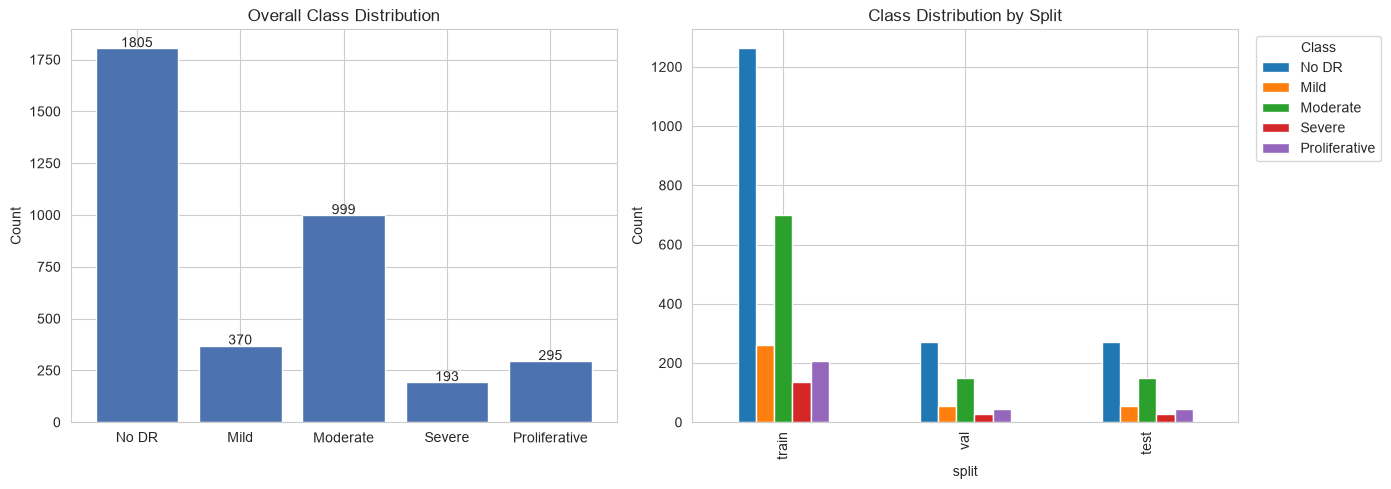

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overall_counts = split_df[LABEL_COL].value_counts().sort_index()
axes[0].bar([CLASS_NAMES[i] for i in overall_counts.index], overall_counts.values, color="#4C72B0")
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(overall_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center")

split_counts = split_df.groupby("split")[LABEL_COL].value_counts().unstack().fillna(0)
split_counts = split_counts.loc[["train", "val", "test"]]
split_counts.columns = [CLASS_NAMES[c] for c in split_counts.columns]
split_counts.plot(kind="bar", stacked=False, ax=axes[1])
axes[1].set_title("Class Distribution by Split")
axes[1].set_ylabel("Count")
axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### What this output means

These two charts show how many images belong to each diagnosis class, first for the whole dataset, then broken down by train, validation, and test group.

Points to note:
- "No DR" (no diabetic retinopathy) is by far the largest class in the dataset.
- Mild, Moderate, Severe, and Proliferative all have far fewer images, with Severe being the smallest group.
- This uneven split between classes is called class imbalance. It means a model trained on this data will see many more healthy examples than disease examples, which can make the rarer, more serious cases harder to detect correctly.
- The pattern looks the same across train, validation, and test, confirming that the stratified split worked as intended.

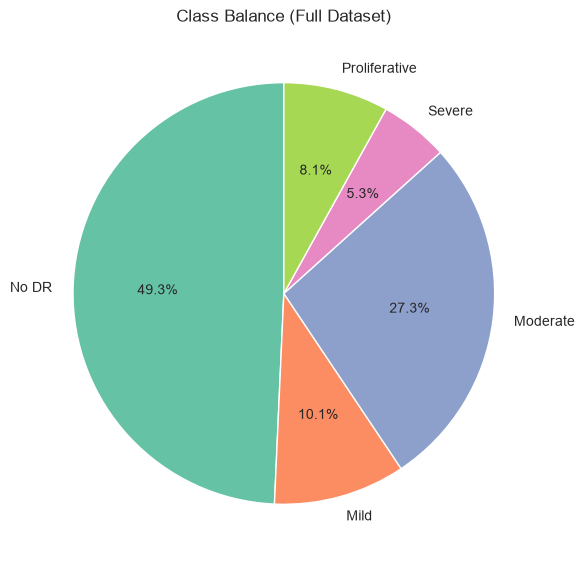

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
overall_counts.index = [CLASS_NAMES[i] for i in overall_counts.index]
ax.pie(overall_counts.values, labels=overall_counts.index, autopct="%1.1f%%",
       colors=sns.color_palette("Set2"), startangle=90)
ax.set_title("Class Balance (Full Dataset)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_balance_pie.png", dpi=150)
plt.show()


This pie chart shows the same class distribution as percentages, which makes the imbalance easier to see at a glance.

- Each slice is one diagnosis class shown as a percentage of the full dataset.
- The "No DR" slice takes up the largest share by a wide margin.
- This kind of imbalance is common in real medical datasets, since most people who get screened do not have advanced disease.

## 3. Image-level scan: paths, resolution, brightness, contrast, black-border fraction

In [8]:
def crop_retinal_field(img, threshold=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]


rows, missing, unreadable = [], [], []
for _, r in tqdm(split_df.iterrows(), total=len(split_df), desc="EDA scan"):
    path = os.path.join(IMAGE_DIR, f"{r[ID_COL]}{IMG_EXT}")
    if not os.path.exists(path):
        missing.append(path); continue
    img = cv2.imread(path)
    if img is None:
        unreadable.append(path); continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    cropped = crop_retinal_field(img_rgb)
    ch, cw = cropped.shape[:2]
    rows.append({
        ID_COL: r[ID_COL], LABEL_COL: r[LABEL_COL], "split": r["split"],
        "height": h, "width": w, "aspect_ratio": w / h if h else np.nan,
        "brightness_mean": float(gray.mean()), "contrast_std": float(gray.std()),
        "black_border_fraction": 1.0 - (ch * cw) / (h * w) if h * w else np.nan,
    })

eda_report = pd.DataFrame(rows)
eda_report.to_csv(f"{FIGURES_DIR}/eda_image_report.csv", index=False)

print(f"Total: {len(split_df)}  Missing: {len(missing)}  Unreadable: {len(unreadable)}")
if missing:
    print("First few missing:", missing[:5])
if unreadable:
    print("First few unreadable:", unreadable[:5])

eda_report.describe()


EDA scan: 100%|██████████| 3662/3662 [06:52<00:00,  8.87it/s]


Total: 3662  Missing: 0  Unreadable: 0


,diagnosis,height,width,aspect_ratio,brightness_mean,contrast_std,black_border_fraction
count,3662.000000,3662.000000,3662.000000,3662.000000,3662.000000,3662.000000,3662.000000
mean,1.126980,1526.830147,2015.176679,1.283818,66.792018,38.805528,0.092513
std,1.298409,542.663120,884.301940,0.182116,17.977345,9.741881,0.119476
min,0.000000,358.000000,474.000000,1.000000,14.966184,9.611584,0.000000
25%,0.000000,1050.000000,1050.000000,1.000000,52.073071,31.650746,0.000000
50%,1.000000,1536.000000,2144.000000,1.333333,68.966838,40.131817,0.056000
75%,2.000000,1958.000000,2588.000000,1.391705,80.837296,45.407625,0.155784
max,4.000000,2848.000000,4288.000000,1.505618,129.618188,75.852629,0.397675


This step goes through every image in the dataset one by one and checks four things: whether the file can actually be opened, its resolution, how bright and how sharp in contrast it looks, and how much of the image is just black border with no useful eye tissue. The summary table shows the average, spread, minimum, and maximum for these measurements across all 3662 images.

- Image sizes vary widely, from about 358 by 474 pixels up to 2848 by 4288 pixels, so every image will need to be resized to one common size before training a model.
- Average brightness is about 67 and average contrast is about 39, but both vary a lot across images, which shows that lighting conditions were not the same for every photo taken.
- On average, about 9 percent of each raw image is just black background with no eye visible. Some images have as much as 40 percent black border, which needs to be cropped out before the images are used for training.

## 4. Resolution distribution

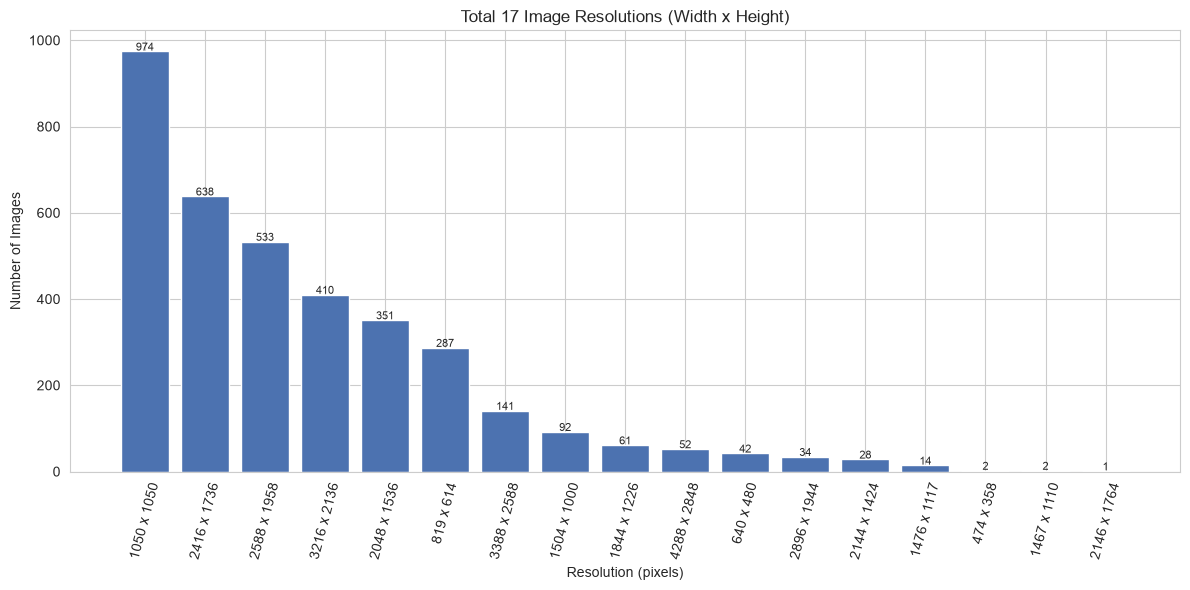

Total distinct resolutions in dataset: 17


In [21]:
# Bar chart: count of images at each distinct resolution (width x height)
resolution_counts = (
    eda_report.assign(resolution=eda_report["width"].astype(str) + " x " + eda_report["height"].astype(str))
    ["resolution"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(resolution_counts.index, resolution_counts.values, color="#4C72B0", )
ax.set_title(f"Total 17 Image Resolutions (Width x Height)")
ax.set_xlabel("Resolution (pixels)")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=75)

for bar, count in zip(bars, resolution_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 2, str(count), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/resolution_bar_chart.png", dpi=150)
plt.show()

print(f"Total distinct resolutions in dataset: {resolution_counts.shape[0]}")

This chart counts how many images share each exact resolution (width by height in pixels), and shows every distinct resolution found in the dataset, ordered from most common to least common.

- The dataset contains only 17 distinct resolutions in total, despite having 3662 images. This means most images are not randomly sized, they cluster into a small set of standard sizes, most likely coming from a handful of different camera or scanner models used during data collection.
- The most common resolution, 1050 x 1050, accounts for 974 images on its own, close to a quarter of the entire dataset. The next few most common sizes (2416 x 1736, 2588 x 1958, 3216 x 2136, 2048 x 1536) together make up another large share.
- The remaining resolutions drop off sharply, with several sizes appearing only a handful of times (as few as 1 or 2 images). These very rare resolutions are likely one-off images from an uncommon device and are not a concern on their own, but they do confirm that a resizing step is essential before training, since the model cannot handle inputs of different sizes.
- Some resolutions are square (such as 1050 x 1050), while most others are rectangular with a wider width than height. This mix of aspect ratios means resizing to a fixed square size (224 x 224, as used later in preprocessing) will stretch or distort images differently depending on which original resolution they came from, which is worth keeping in mind when interpreting model behavior.

## 5. Brightness and contrast distributions

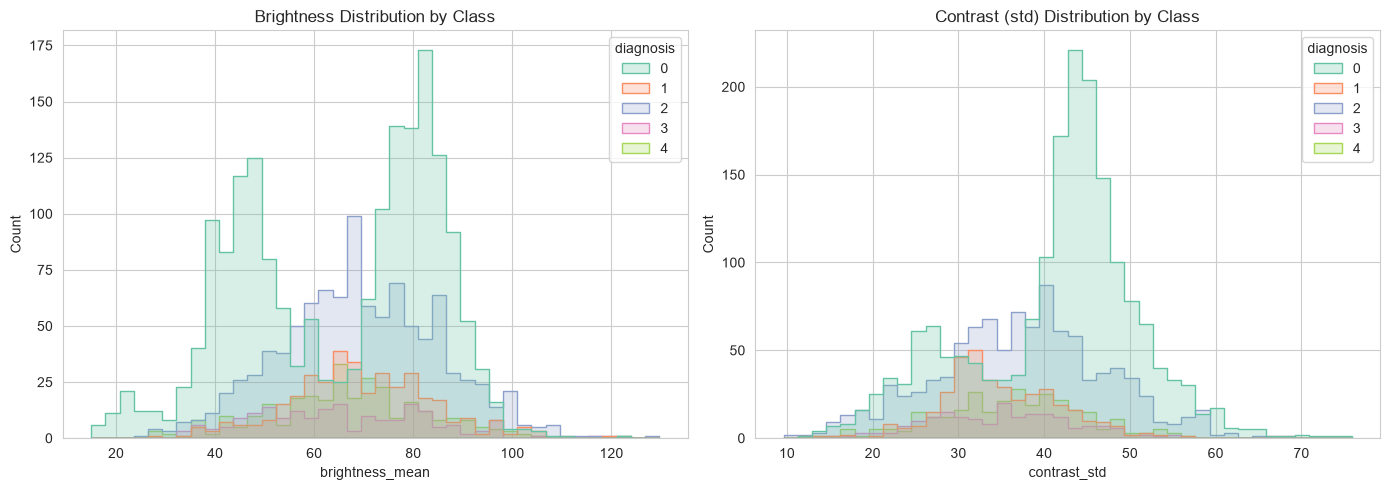

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=eda_report, x="brightness_mean", hue=LABEL_COL, palette="Set2",
             bins=40, ax=axes[0], element="step")
axes[0].set_title("Brightness Distribution by Class")

sns.histplot(data=eda_report, x="contrast_std", hue=LABEL_COL, palette="Set2",
             bins=40, ax=axes[1], element="step")
axes[1].set_title("Contrast (std) Distribution by Class")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/brightness_contrast_distribution.png", dpi=150)
plt.show()


These charts show how brightness and contrast are spread out for each diagnosis class.
- If different classes had clearly different brightness or contrast on average, that could mean a model might learn to guess the class from lighting alone rather than from real disease signs, which would be misleading.
- Here, brightness and contrast overlap heavily across all classes, meaning there is no obvious shortcut pattern based on lighting.
- This is a useful check to run before training, since it helps rule out an easy but incorrect way for a model to appear accurate.

## 6. Black-border fraction (how much of each raw image is unusable border)

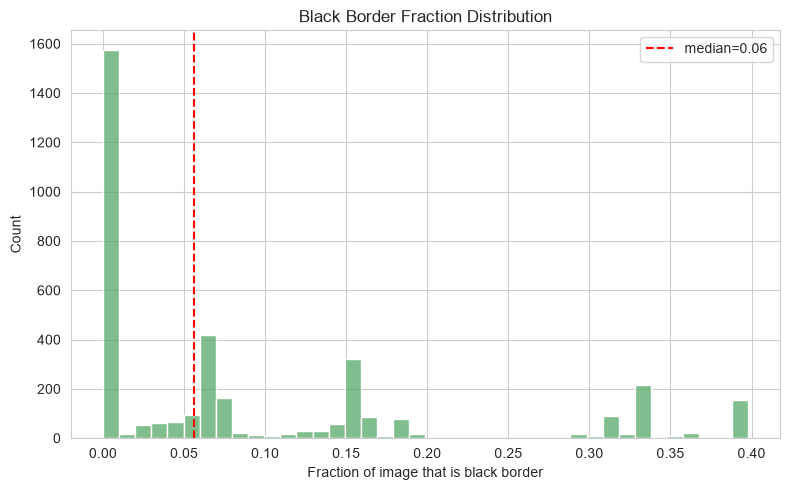

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(eda_report["black_border_fraction"], bins=40, ax=ax, color="#55A868")
ax.set_title("Black Border Fraction Distribution")
ax.set_xlabel("Fraction of image that is black border")
ax.axvline(eda_report["black_border_fraction"].median(), color="red", linestyle="--",
           label=f"median={eda_report['black_border_fraction'].median():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/black_border_distribution.png", dpi=150)
plt.show()


This chart shows how much of each image, on average, is just black border rather than actual eye tissue.
- The red dashed line marks the median value, meaning half of all images have less black border than this line, and half have more.
- Most images have a relatively small black border, but a smaller number of images have a much larger border.
- This supports the plan to crop images before resizing, so that the model focuses on the eye itself instead of empty black space.

## 7. Brightness vs. contrast, coloured by class (spot outliers / mislabeled-looking images)

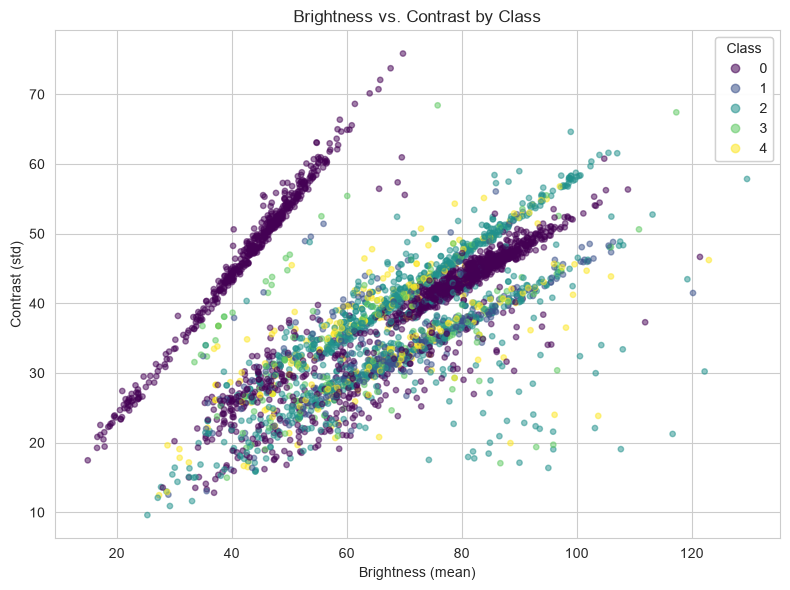

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(eda_report["brightness_mean"], eda_report["contrast_std"],
                      c=eda_report[LABEL_COL], cmap="viridis", alpha=0.5, s=15)
legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)
ax.set_xlabel("Brightness (mean)")
ax.set_ylabel("Contrast (std)")
ax.set_title("Brightness vs. Contrast by Class")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/brightness_vs_contrast.png", dpi=150)
plt.show()


This chart plots brightness against contrast for every single image, with each dot colored by its diagnosis class.
- The purpose of this chart is to help spot unusual images, for example ones that are unusually dark, unusually bright, or unusually flat, which could be lower quality scans worth a closer look.
- The colors are mixed together across the chart rather than forming separate groups, which again suggests that brightness and contrast alone do not clearly separate the classes.
- Any dots sitting far away from the main cluster of points could be worth checking manually, since they may point to image quality issues rather than true disease patterns.

## 8. Sample images : one row per class

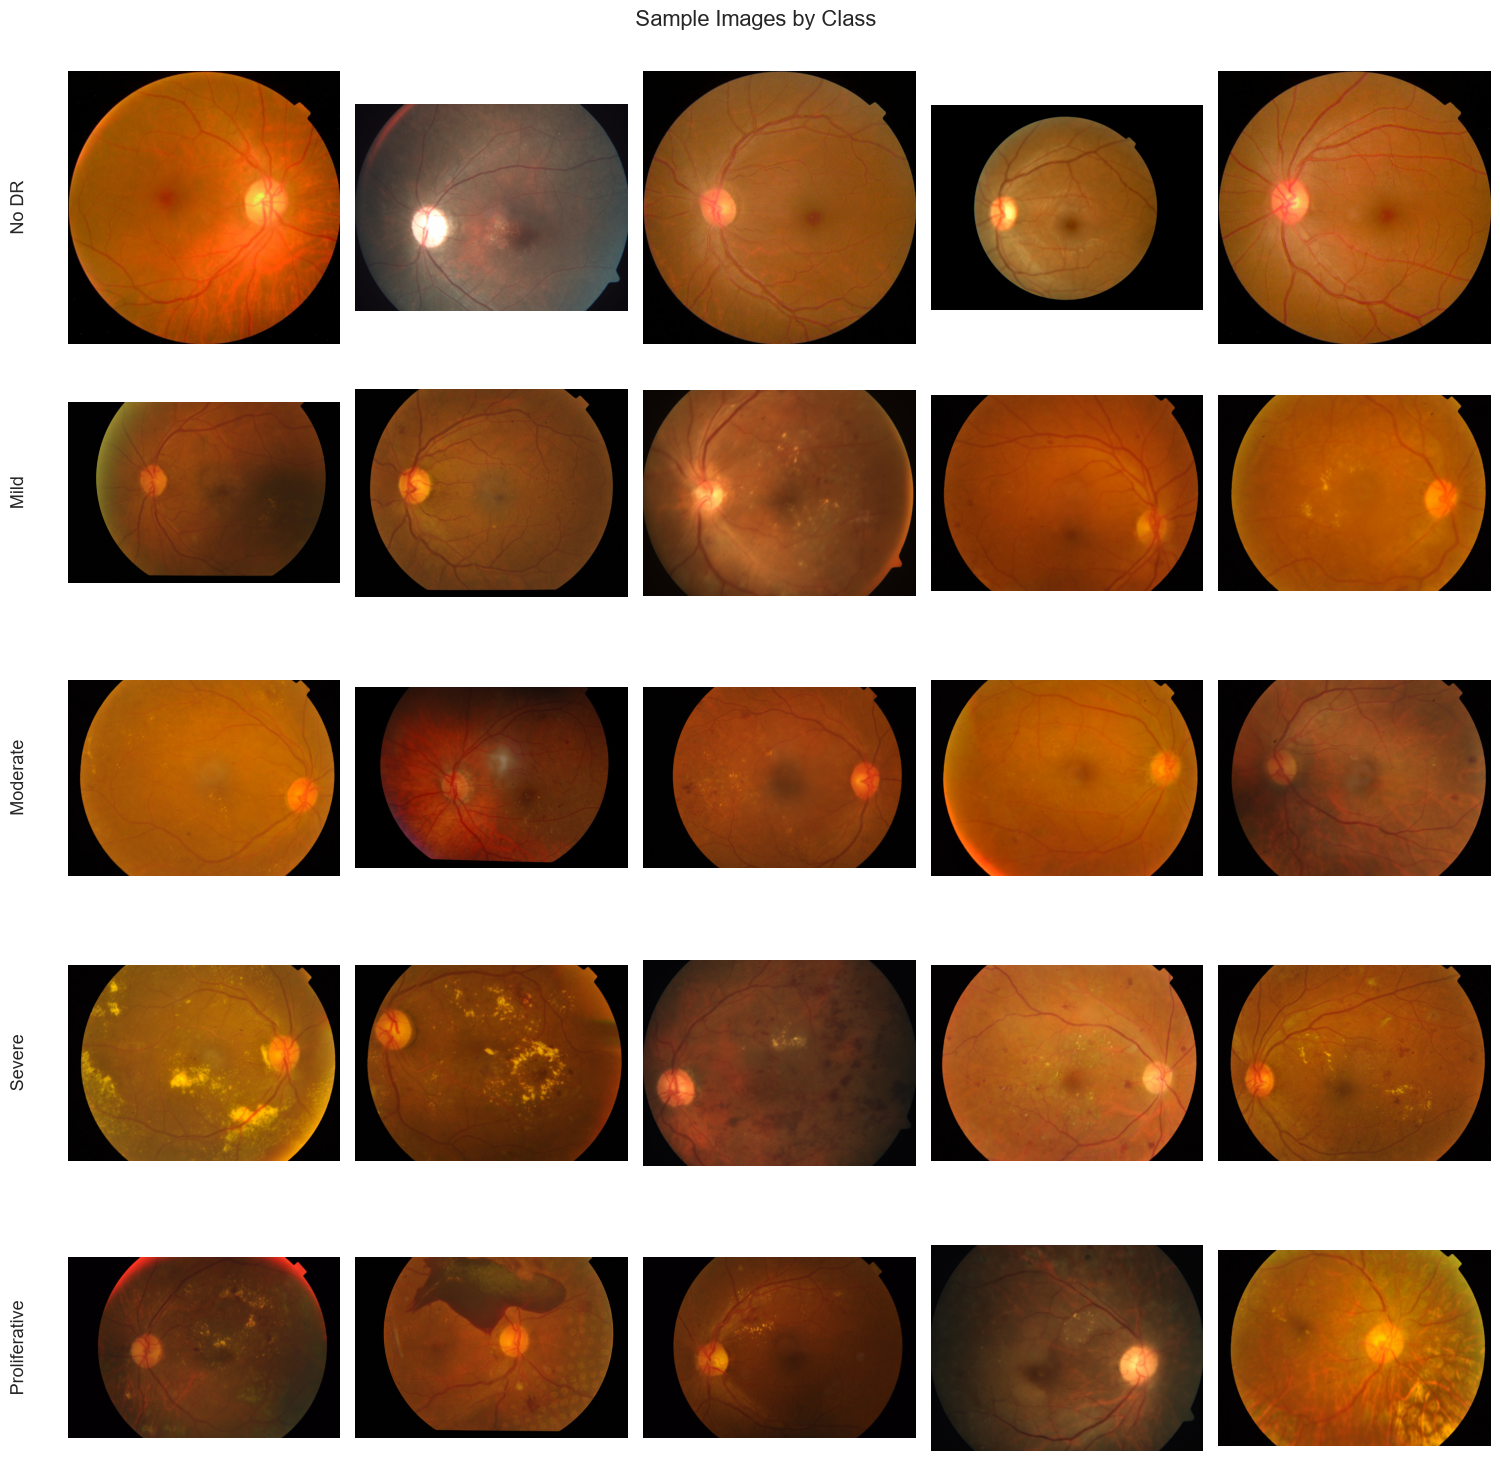

In [13]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for cls in range(5):
    cls_df = split_df[(split_df[LABEL_COL] == cls) & (split_df["split"] == "train")]
    sample = cls_df.sample(min(5, len(cls_df)), random_state=SEED)
    for j, (_, row) in enumerate(sample.iterrows()):
        path = os.path.join(IMAGE_DIR, f"{row[ID_COL]}{IMG_EXT}")
        img = cv2.imread(path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[cls, j].imshow(img_rgb)
        axes[cls, j].axis("off")
        if j == 0:
            axes[cls, j].set_ylabel(CLASS_NAMES[cls], fontsize=12)
    for j in range(len(sample), 5):
        axes[cls, j].axis("off")

for cls in range(5):
    axes[cls, 0].text(-0.15, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                       fontsize=13, va="center", ha="right", rotation=90)

plt.suptitle("Sample Images by Class", fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sample_images_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


- Each row represents one diagnosis class, from "No DR" at the top to "Proliferative" at the bottom.
- Looking at real examples like this helps confirm that the labels make sense and gives a feel for how subtle or obvious the differences between classes can be to the eye.
- This is especially useful for anyone without a medical background, since it turns abstract class numbers into actual pictures that are easier to relate to.